In [8]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

In [9]:
db_file = "../data/checking-logs.sqlite"
conn = sqlite3.connect(db_file)

In [10]:
df_ab = pd.read_csv('../data/ab-test.csv')

In [11]:
test_users = df_ab[df_ab['group'] == 'test']['uid'].unique()
test_users

<StringArray>
['user_1', 'user_18', 'user_19', 'user_21', 'user_25', 'user_28', 'user_3']
Length: 7, dtype: str

In [12]:
query_checker = """
SELECT uid, AVG(diff) AS avg_diff, SUM(cnt) AS num_commits
FROM (
    SELECT 
        c.uid, 
        CAST((strftime('%s', MIN(c.timestamp)) - d.deadlines) / 3600.0 AS INTEGER) AS diff,
        COUNT(c.timestamp) as cnt
    FROM checker c
    LEFT JOIN deadlines d ON c.labname = d.labs
    WHERE c.uid LIKE 'user_%' AND c.labname != 'project1'
    GROUP BY c.uid, c.labname
)
GROUP BY uid
"""
df_checker = pd.read_sql(query_checker, conn)

In [13]:
query_views = """
SELECT uid, COUNT(*) AS pageviews
FROM pageviews
WHERE uid LIKE 'user_%'
GROUP BY uid
"""
df_views = pd.read_sql(query_views, conn)

In [14]:
conn.close()

In [15]:
df_checker = df_checker[df_checker['uid'].isin(test_users)]
df_final = pd.merge(df_checker, df_views, on='uid')
df_plot = df_final[['avg_diff', 'pageviews', 'num_commits']]
print(len(df_plot))

7


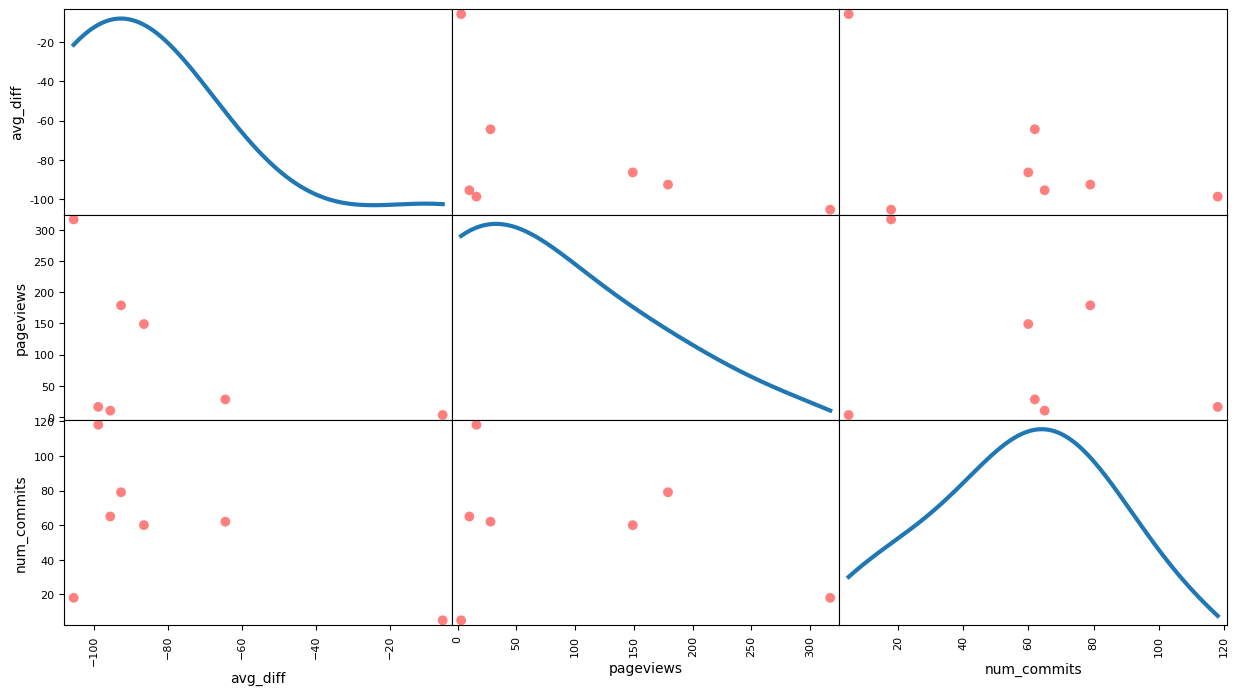

In [17]:
df_plot = df_final[['avg_diff', 'pageviews', 'num_commits']]
ax = scatter_matrix(df_plot, figsize=(15, 8), diagonal='kde', s=200, color='red', density_kwds={'linewidth': 3})

1. Can we say that if a user has a low number of pageviews, then they likely have a low number of commits?
Ans. NO

2. Can we say that if a user has a low number of pageviews, then they likely have a small average difference between the first commit and the lab deadline?
Ans. NO

3. Can we say that there are many users with a low number of commits and a few with a high number of commits?
Ans. YES

4. Can we say that there are many users with a small average difference and a few with a large average difference?
Ans. NO